# Assignment 6 — Generation Experiment

**DATAX504** · Due end of Week 11

Choose **text** or **image** generation. This notebook is intentionally sparse: pick a small, runnable experiment you can defend in the reflection.

## Tasks
1. Train or adapt a small generator (char-RNN / small LM, GAN, VAE, simple diffusion demo, …)
2. Show **5 samples** in this notebook
3. Name the main **failure mode** you observed
4. After reading the [HF diffusion language models post](https://huggingface.co/blog/ProCreations/diffusion-language-model), write ~150 words on AR vs diffusion trade-offs

## Moodle fields
`a6_repo`, `a6_modality`, `a6_failure`, `a6_diffusion_reflection`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model |Claude |
| Used for | Helped me understand the assignment requirements, structure the character-level GRU experiment, explain the code, and draft/refine the written reflection.|
| Verified how | I ran the notebook from start to finish, checked that the model trained without errors, confirmed that the loss output was produced, and inspected the five generated text samples.|
| Not used for | I did not use AI to generate or falsely report experimental results. The model training and five generated samples were produced by running my notebook.|


In [4]:
import os, numpy as np, tensorflow as tf
keras.utils.set_random_seed(42)

# --- Data: Tiny Shakespeare (~1.1M characters), from the TensorFlow text-generation tutorial ---
path = keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt')
text = open(path, 'rb').read().decode('utf-8')
vocab = sorted(set(text))
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = np.array(vocab)
data = np.array([char2idx[c] for c in text], dtype='int32')
print("Characters:", len(text), "| Vocabulary size:", len(vocab))
print(text[:200])

SEQ_LEN, BATCH = 100, 64
split = int(0.95 * len(data))          # last 5% held out for validation

def make_ds(arr, shuffle):
    ds = tf.data.Dataset.from_tensor_slices(arr).batch(SEQ_LEN + 1, drop_remainder=True)
    ds = ds.map(lambda c: (c[:-1], c[1:]))          # input = characters 0..99, target = characters 1..100
    if shuffle:
        ds = ds.shuffle(10000, seed=42)
    return ds.batch(BATCH, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(data[:split], shuffle=True)
val_ds = make_ds(data[split:], shuffle=False)
x, y = next(iter(train_ds))
print("Batch:", x.shape, y.shape)

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Characters: 1115394 | Vocabulary size: 65
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you
Batch: (64, 100) (64, 100)


## Experiment

Implement **one** modality below (remove or ignore the other).

Keep the scope small enough to train on a laptop. Document data source, training setup, and how you sampled outputs.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 256)      │       247,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 65)       │        16,705 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,161 (1.02 MB)

 Trainable params: 268,161 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
163/163 - 89s - 545ms/step - loss: 2.6720 - val_loss: 2.2424
Epoch 2/15
163/163 - 79s - 485ms/step - loss: 2.1055 - val_loss: 2.0127
Epoch 3/15
163/163 - 83s - 508ms/step - loss: 1.8878 - val_loss: 1.8821
Epoch 4/15
163/163 - 80s - 493ms/step - loss: 1.7493 - val_loss: 1.8018
Epoch 5/15
163/163 - 89s - 548ms/step - loss: 1.6564 - val_loss: 1.7403
Epoch 6/15
163/163 - 136s - 833ms/step - loss: 1.5906 - val_loss: 1.7005
Epoch 7/15
163/163 - 80s - 492ms/step - loss: 1.5418 - val_loss: 1.6744
Epoch 8/15
163/163 - 80s - 491ms/step - loss: 1.5046 - val_loss: 1.6537
Epoch 9/15
163/163 - 81s - 498ms/step - loss: 1.4745 - val_loss: 1.6417
Epoch 10/15
163/163 - 79s - 485ms/step - loss: 1.4502 - val_loss: 1.6274
Epoch 11/15
163/163 - 83s - 510ms/step - loss: 1.4296 - val_loss: 1.6174
Epoch 12/15
163/163 - 84s - 516ms/step - loss: 1.4124 - val_loss: 1.6123
Epoch 13/15
163/163 - 85s - 521ms/step - loss: 1.3967 - val_loss: 1.6032
Epoch 14/15
163/163 - 139s - 853ms/step - loss: 1.3833 - va

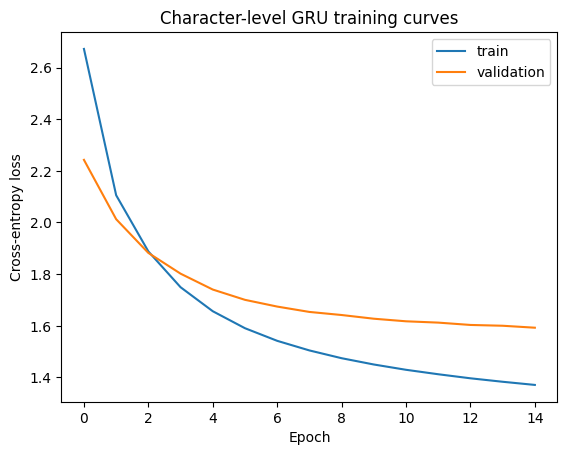

Best validation loss: 1.593 (perplexity 4.92)


In [5]:
EPOCHS = 15
model = keras.Sequential([
    layers.Input(shape=(None,), dtype='int32'),
    layers.Embedding(len(vocab), 64),
    layers.GRU(256, return_sequences=True),
    layers.Dense(len(vocab)),                      # one score (logit) per possible next character
])
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True))
model.summary()

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                    callbacks=callbacks, shuffle=False, verbose=2)

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss'); plt.legend()
plt.title('Character-level GRU training curves'); plt.show()
best_val = min(history.history['val_loss'])
print(f"Best validation loss: {best_val:.3f} (perplexity {np.exp(best_val):.2f})")

In [6]:
def generate(prompt, n_chars=400, temperature=0.8, seed=None):
    """Sample one character at a time from the model's predicted distribution."""
    rng = np.random.default_rng(seed)
    ids = [char2idx[c] for c in prompt]
    for _ in range(n_chars):
        ctx = np.array([ids[-SEQ_LEN:]], dtype='int32')               # last 100 characters
        logits = model(ctx, training=False)[0, -1].numpy() / temperature
        p = np.exp(logits - logits.max()); p /= p.sum()               # softmax with temperature
        ids.append(int(rng.choice(len(vocab), p=p)))
    return ''.join(idx2char[i] for i in ids)

prompts = ["ROMEO:\n", "First Citizen:\n", "JULIET:\n", "KING HENRY:\n", "HAMLET:\n"]

print("=== 5 samples (temperature 0.8) ===")
for i, pr in enumerate(prompts):
    print(f"\n--- Sample {i+1} (prompt: {pr.strip()!r}) ---")
    print(generate(pr, 400, 0.8, seed=i))

print("\n=== Failure-mode probes (same prompt, different temperature) ===")
for T in (0.2, 1.2):
    print(f"\n--- temperature {T} ---")
    print(generate("ROMEO:\n", 400, T, seed=0))

=== 5 samples (temperature 0.8) ===

--- Sample 1 (prompt: 'ROMEO:') ---
ROMEO:
Peace, thou wast of Gloucester, as it were her master
For hand the widow: heney then thou woest?
For her kish'd thee, that's friar, the stumble holy tale.

SICINIUS:
How it heirs, what besides at Durs and my lord
Shall stand thee there forth? not was how it to him,
I have put out on the offence's streathed,' and pass
The common things of England'st,
So it in the Volsces so beggars to lost,
Where i

--- Sample 2 (prompt: 'First Citizen:') ---
First Citizen:
Look my lard! and hear you have not?

KATHARINA:
The reason have finds not answer the thing
Ladial to the may be so heartalf dance put this blood:
They come not your honry of part; for humbly high in soon:
Now King a confule than do? which change conscience
And have you miss. The border preccys;
Obable messech upon the cublat again.

MARIANA:
Now thou art passion!

JULIET:
Ay, good men, in your de

--- Sample 3 (prompt: 'JULIET:') ---
JULIET:
Here is he d

## Failure mode (Moodle `a6_failure`)

One short phrase is enough for Moodle (e.g. repetition, mode collapse, blur). Expand briefly below if useful.


Repetition and loss of long-range coherence

## AR vs diffusion reflection (Moodle `a6_diffusion_reflection`)

~150 words after the HF reading: compare autoregressive vs diffusion-style generation for *your* modality (quality, control, compute, failure modes).


Autoregressive (AR) and diffusion language models make different trade-offs. In my experiment, the character-level GRU generates text one character at a time, conditioning only on the previous characters (the last 100 in my sampler). This is simple and efficient to train and sample for short text, but generation is inherently sequential, so long outputs are slow, and early mistakes cannot be revised. It also showed the typical AR failure: text that looks locally plausible but repeats itself and loses long-range coherence. Diffusion language models instead start from masked or noisy text and refine it over several denoising steps. Because many tokens are updated in parallel and the whole sequence can be revisited, they can use more global context, give more control (for example infilling or editing), and may need fewer sequential steps. The cost is multiple denoising passes and more complex training and tuning. Overall, AR is the simpler, proven choice for straightforward generation, while diffusion is promising where parallelism, control and refinement matter.